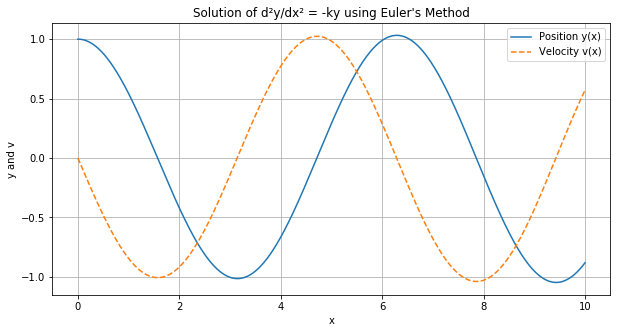

In [15]:
import numpy as np
import matplotlib.pyplot as plt
# Define the parameters
k = 1.0        # Constant in the equation (e.g., spring constant)
h = 0.01       # Step size
x_start = 0    # Start of the interval
x_end = 10     # End of the interval
y_0 = 1.0      # Initial condition for y
v_0 = 0.0      # Initial condition for dy/dx
# Create arrays to store x, y, and v values
x_values = np.arange(x_start, x_end + h, h)
y_values = np.zeros(len(x_values))
v_values = np.zeros(len(x_values))
# Set initial conditions
y_values[0] = y_0
v_values[0] = v_0

# Euler's Method loop
for i in range(1, len(x_values)):
    # Current values
    x_n = x_values[i - 1]
    y_n = y_values[i - 1]
    v_n = v_values[i - 1]    
    # Update equations
    y_values[i] = y_n + h * v_n
    v_values[i] = v_n + h * (-k * y_n)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(x_values, y_values, label='Position y(x)')
plt.plot(x_values, v_values, label='Velocity v(x)', linestyle='--')
plt.xlabel('x')
plt.ylabel('y and v')
plt.title('Solution of d²y/dx² = -ky using Euler\'s Method')
plt.legend()
plt.grid(True)
plt.show()

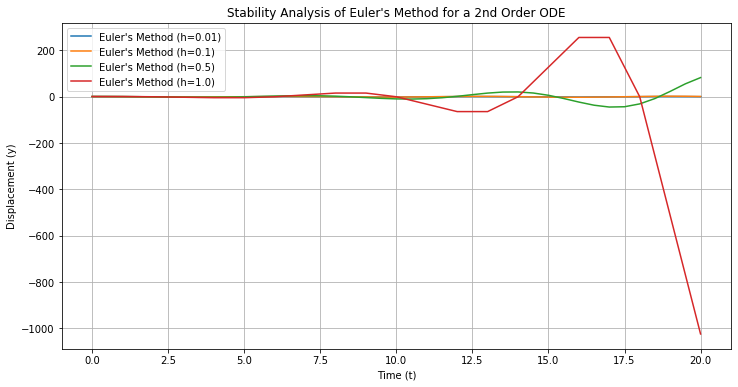

In [16]:
import numpy as np
import matplotlib.pyplot as plt
# Parameters
k = 1.0        # Spring constant
h_values = [0.01, 0.1, 0.5, 1.0]  # Different step sizes to test stability
t_start = 0    # Start time
t_end = 20     # End time
y_0 = 1.0      # Initial displacement
v_0 = 0.0      # Initial velocity
# Function to apply Euler's Method for given step size

def euler_method(h, k, t_start, t_end, y_0, v_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))    
    # Set initial conditions
    y_values[0] = y_0
    v_values[0] = v_0

    for i in range(1, len(t_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]        
        # Update equations for Euler's Method
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n)   
    return t_values, y_values
# Plot results for different step sizes
plt.figure(figsize=(12, 6))

for h in h_values:
    t, y = euler_method(h, k, t_start, t_end, y_0, v_0)
    plt.plot(t, y, label=f'Euler\'s Method (h={h})')
plt.xlabel('Time (t)')
plt.ylabel('Displacement (y)')
plt.title('Stability Analysis of Euler\'s Method for a 2nd Order ODE')
plt.legend()
plt.grid(True)
plt.show()

Solution may not be entirely stable ;)
Current Step Size: 0.01
Solution may not be entirely stable ;)
Current Step Size: 0.1
Solution may not be entirely stable ;)
Current Step Size: 0.5
Solution may not be entirely stable ;)
Current Step Size: 1.0


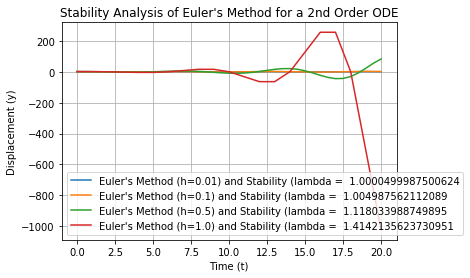

In [17]:




def coeffEulerMatrix(k, h):
    eigenValueList = []
    coeffMatrix = ([[1, h], [h*-k, 1]])
    eigenValue = np.max(np.abs(np.linalg.eigvals(coeffMatrix)))
    if eigenValue <= 1:
        print("Solution is stable")
        print(f"Current Step Size: {h}")
    else:
        print("Solution may not be entirely stable ;)")
        print(f"Current Step Size: {h}")
    return eigenValue
    
# Parameters
k = 1.0        # Spring constant
h_values = [0.01, 0.1, 0.5, 1.0]  # Different step sizes to test stability
t_start = 0    # Start time
t_end = 20     # End time
y_0 = 1.0      # Initial displacement
v_0 = 0.0      # Initial velocity
# Function to apply Euler's Method for given step size

for h in h_values:
    t, y = euler_method(h, k, t_start, t_end, y_0, v_0)
    lambdaCo = coeffEulerMatrix(k, h)
    plt.plot(t, y, label=f'Euler\'s Method (h={h}) and Stability (lambda =  {lambdaCo}')

plt.xlabel('Time (t)')
plt.ylabel('Displacement (y)')
plt.title('Stability Analysis of Euler\'s Method for a 2nd Order ODE')
plt.legend()
plt.grid(True)
plt.show()


All of the lambdas indicate unstability, meaning that for this system, the method is unstable.